In [1]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.integrate import solve_ivp

### Van der Pol Oscillator
$$
    {d^2x\over dt^2}-\mu(1-x^2){dx\over dt}+x = 0
$$
or as a system
\begin{align}
\dot x_1 & = x_2 \cr
\dot x_2 &= \mu(1-x_1^2)x_2-x_1\cr
\end{align}
https://en.wikipedia.org/wiki/Van_der_Pol_oscillator

Notice that $(0,0)$ is the only fixed point and the Jacobian of the vector field is
$$
    J = \begin{bmatrix} 0 & 1\cr -1 - 2\mu x_1 x_2 & \mu(1-x_1^2)\cr\end{bmatrix}.
$$

If $(x_1,x_2)$ is a equilibrium point then $x_2=0$ from the first component.  Then $x_1=0$ as well.  That is $(0,0)$ is the only equilibrium point for this system.

In [2]:
from sympy import symbols, Matrix, diff
x1,x2,μ = symbols('x_1 x_2 μ')
J = Matrix([
    [0,1],[-1-2*μ*x1*x2,μ*(1-x1**2)]
])
J

Matrix([
[               0,              1],
[-2*x_1*x_2*μ - 1, μ*(1 - x_1**2)]])

In [3]:
J.subs(x1,0).subs(x2,0).charpoly()

PurePoly(lambda**2 - μ*lambda + 1, lambda, domain='ZZ[μ]')

In [4]:
Matrix(list(J.subs(x1,0).subs(x2,0).eigenvals().keys()))

Matrix([
[μ/2 - sqrt((μ - 2)*(μ + 2))/2],
[μ/2 + sqrt((μ - 2)*(μ + 2))/2]])

## Functions and parameters

In [6]:
μ = -0.5
def J(x1,x2):
    return np.array([[0,1],[-1-2*μ*x1*x2,μ*(1-x1**2)]])
def vanderpol(t,xx):
    x1,x2 = xx
    return [x2,μ*(1-x1**2)*x2 - x1]

### Region of study
The restrictions
$$
    a\le x_1 \le b \quad c\le x_2 \le c
$$
define a rectangular region $R$.

Text(0.5, 1.0, 'Van der Pol vector field')

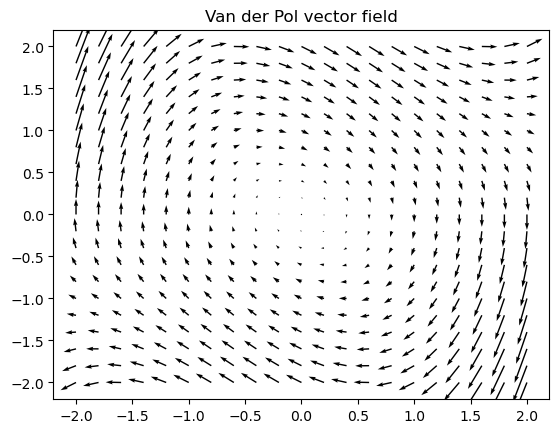

In [7]:
a,b = -2,2 # x1 limits
c,d = -2,2 # x2 limits
npts  = 21
x1 = np.linspace(a,b,npts)
x2 = np.linspace(c,d,npts)
X1,X2 = np.meshgrid(x1,x2)
Z1,Z2 = vanderpol(_,(X1,X2))
plt.quiver(X1,X2,Z1,Z2)
plt.title('Van der Pol vector field')

In [8]:
a,b = -5,5 # x1 limits
c,d = -6,6 # x2 limits

## Time interval and Initial Conditions
$$
    (x_{10},x_{20})\in R,\qquad t_0\le t\le t_1
$$

In [17]:
t0,t1 = 0.,120.
Nsols = 400
x10s = (b-a)*np.random.rand(Nsols)+a
x20s = (c-d)*np.random.rand(Nsols)+d
y0s = np.vstack((x10s,x20s)).T
t_span = [t0,t1]

tsteps = 2400
t_eval = np.linspace(t0,t1,tsteps+1)

In [18]:
%matplotlib notebook

<IPython.core.display.Javascript object>


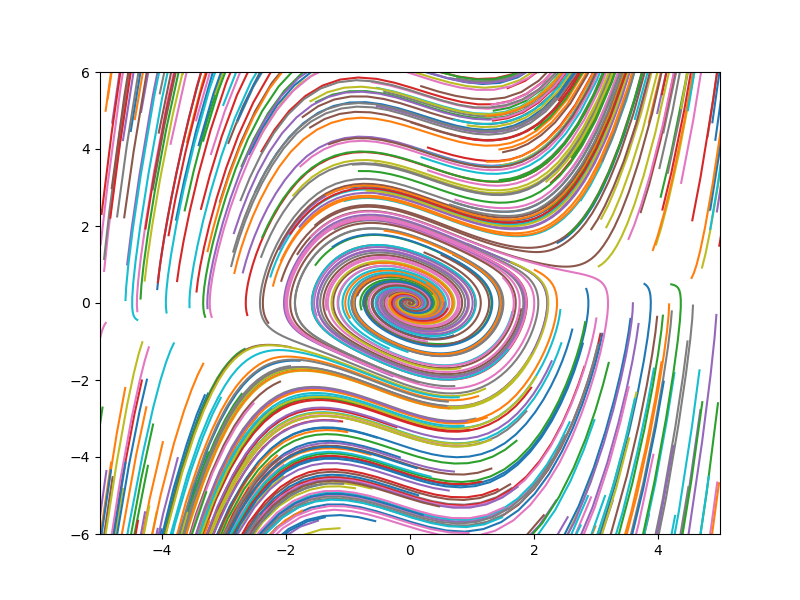

In [20]:
μ = -0.5
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))
    
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

## Poincare-Bendixson Theorem
https://en.wikipedia.org/wiki/Poincar%C3%A9%E2%80%93Bendixson_theorem

Suppose $R$ is a closed annular region of the plane which is forward invariant under the flow for
$$
    \dot x = f(x)
$$
where $f$ is $C^1$ on some open set containing $R$.  Suppose further that $R$ contains no fixed points for $f$.  Then any orbit starting in $R$ either
1. is a closed periodic orbit, or
2. spirals towards a periodic orbit as $t\to\infty$.

<IPython.core.display.Javascript object>


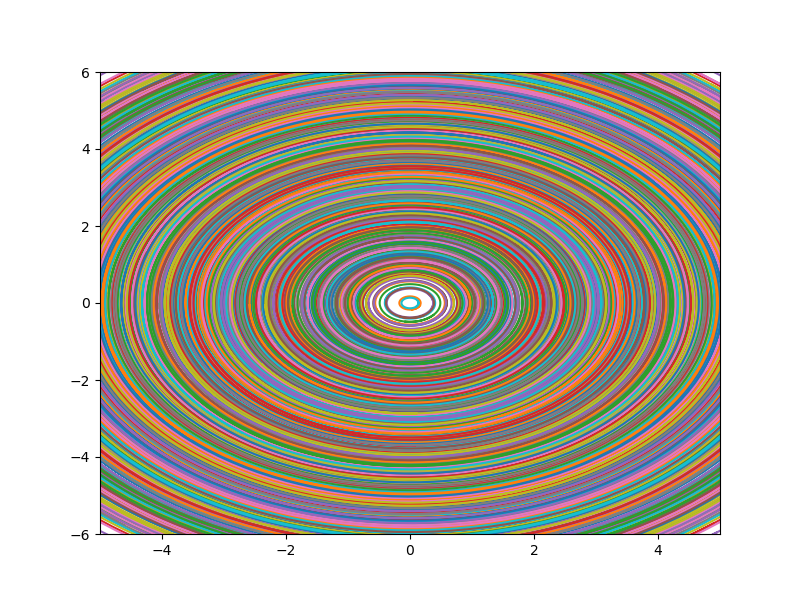

In [12]:
μ = 0
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))
    
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


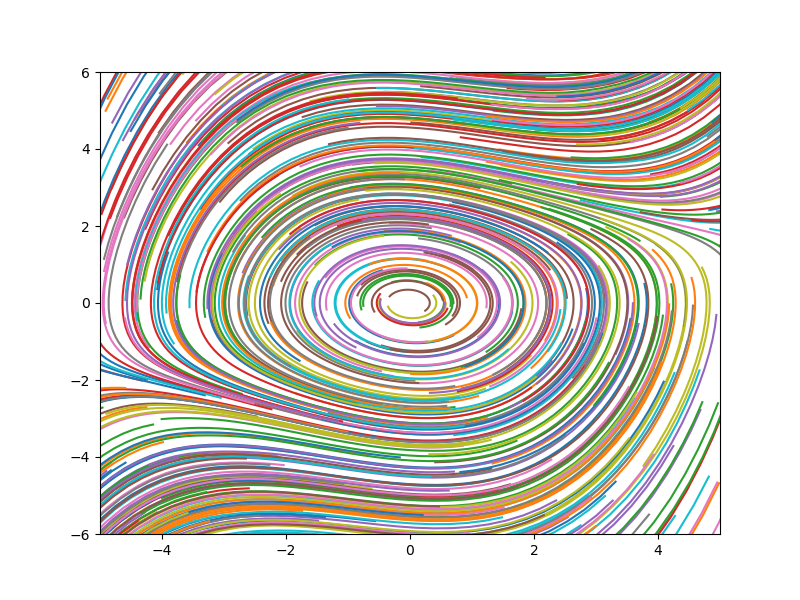

In [21]:
μ = -0.1
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))
    
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


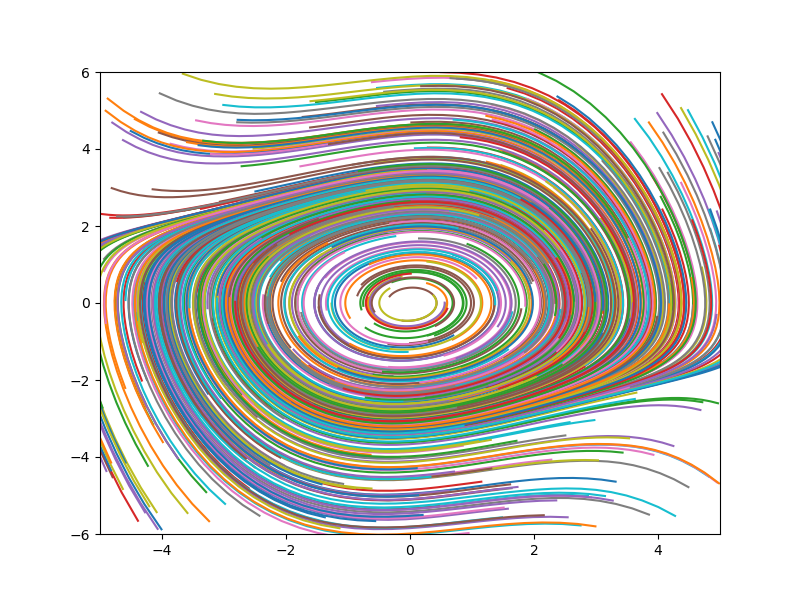

In [22]:
μ = 0.1
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))
    
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


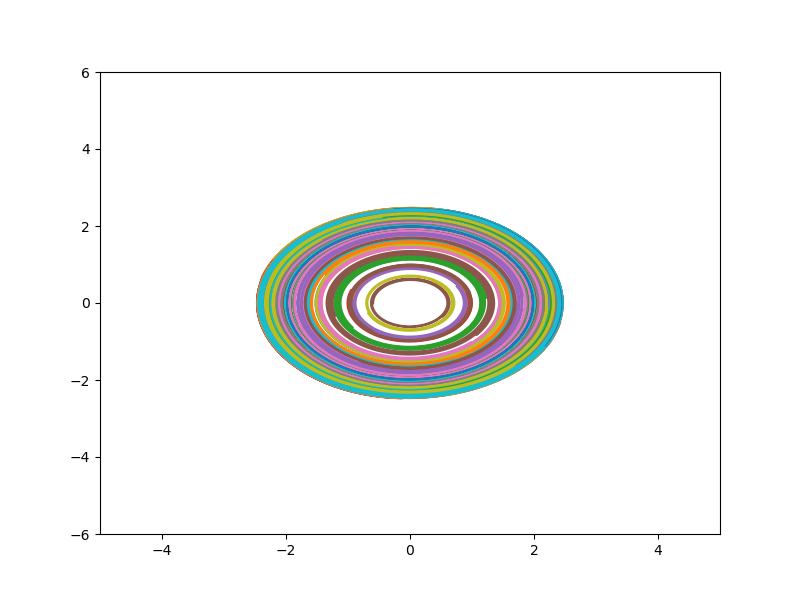

In [26]:
μ = 0.01
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

start = 2000
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

## Duffing's Equation
For an overview, see [Duffing equation](https://en.wikipedia.org/wiki/Duffing_equation)
$$
        \ddot x + \delta \dot x - x + \beta x^3 = \gamma\cos(\omega t)
$$
As a first order system
\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\delta x_2 + x_1(1-x_1^2) + \gamma\cos(\omega t)\cr
\end{align}
Note the cubic stiffness term.

## Functions and parameters

In [27]:
δ = 0.25
γ = 0.30
ω = 1.00
β = 1.00
def duffing(t,xx):
    x1,x2 = xx
    return [x2,-δ*x2+x1*(1-x1**2)+γ*np.cos(ω*t)]

In [28]:
atol,rtol = 1e-8,1e-8
x10,x20 = 1., 1.
periods = 10

period  = 2*π/ω
t0,t1 = 0.,periods*period
t_span = [t0,t1]
y0 = [x10,x20]
t_eval = np.linspace(t0,t1,periods*100+1)

In [29]:
%%time
sol = solve_ivp(duffing,t_span,y0,t_eval=t_eval,atol=atol,rtol=rtol)
sol

CPU times: user 84.6 ms, sys: 12 ms, total: 96.5 ms
Wall time: 87.1 ms


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.283e-02 ...  6.277e+01  6.283e+01]
        y: [[ 1.000e+00  1.063e+00 ...  1.122e+00  1.119e+00]
            [ 1.000e+00  9.989e-01 ... -4.449e-02 -4.295e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 4052
     njev: 0
      nlu: 0

<IPython.core.display.Javascript object>


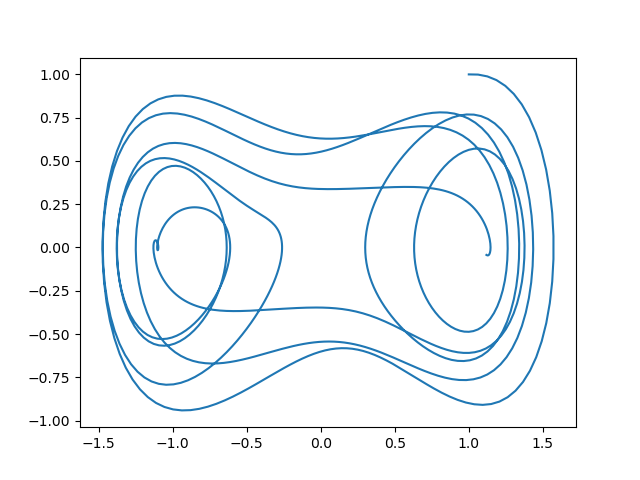

In [30]:
plt.plot(sol.y[0],sol.y[1])